# 00 - Estudio de datos

Notebook para entender `xview_recognition`. Las etiquetas y rutas de train se leen desde `xview_ann_train.json`, como en el ejemplo del profesor, para mantener una fuente unica de etiquetas durante todos los experimentos.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import rasterio
    from rasterio.errors import NotGeoreferencedWarning
    import warnings
    HAS_RASTERIO = True
except Exception as exc:
    HAS_RASTERIO = False
    print('Aviso: rasterio no esta disponible:', exc)


In [2]:
from pathlib import Path

# Kaggle-only: busca automaticamente xview_ann_train.json dentro de /kaggle/input.
# No dependemos del nombre exacto del Dataset en Kaggle.
KAGGLE_INPUT_DIR = Path('/kaggle/input')

if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError(
        'No existe /kaggle/input. Ejecuta este notebook en Kaggle y anade el dataset xview_recognition como Input.'
    )

json_matches = sorted(KAGGLE_INPUT_DIR.rglob('xview_ann_train.json'))
if not json_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro xview_ann_train.json dentro de /kaggle/input. '
        f'Inputs disponibles: {available_inputs}. '
        'Comprueba que has anadido el dataset xview_recognition al notebook.'
    )

ANN_JSON = json_matches[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'

print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


DATA_ROOT: /kaggle/input/datasets/eccvdl/xview-recognition
ANN_JSON: /kaggle/input/datasets/eccvdl/xview-recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


In [3]:
import json

with open(ANN_JSON, 'r', encoding='utf-8') as f:
    json_data = json.load(f)

categories = {int(k): v['name'] for k, v in sorted(json_data['categories'].items(), key=lambda item: int(item[0]))}
category_names = list(categories.values())
category_to_idx = {name: idx for idx, name in categories.items()}

print(categories)
print('Train images in JSON:', len(json_data['images']))
print('Train annotations in JSON:', len(json_data['annotations']))


{0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}
Train images in JSON: 18746
Train annotations in JSON: 18746


In [4]:
rows = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    rows.append({
        'image_id': json_img['image_id'],
        'filename': json_img['filename'],
        'width': json_img['width'],
        'height': json_img['height'],
        'category': json_ann['category_id'],
        'bbox': json_ann['bbox'],
        'exists': (DATA_ROOT / json_img['filename']).exists(),
    })

df = pd.DataFrame(rows)
df.head()


,image_id,filename,width,height,category,bbox,exists
0,0234476c-a017-4c9b-bd2f-872193076cca.tif,xview_train/Building/0234476c-a017-4c9b-bd2f-8...,224,224,Building,"[0, 0, 224, 224]",True
1,f2543073-9933-44c4-98e0-15eee2dffe2a.tif,xview_train/Building/f2543073-9933-44c4-98e0-1...,224,224,Building,"[0, 0, 224, 224]",True
2,6df5b6a5-82b0-4abb-8deb-7d7154c977bc.tif,xview_train/Building/6df5b6a5-82b0-4abb-8deb-7...,224,224,Building,"[0, 0, 224, 224]",True
3,ddbd2636-ce3c-4406-a5cf-92fa557dbd3c.tif,xview_train/Building/ddbd2636-ce3c-4406-a5cf-9...,224,224,Building,"[0, 0, 224, 224]",True
4,609064d1-3719-4163-ad36-577dab9805f0.tif,xview_train/Building/609064d1-3719-4163-ad36-5...,224,224,Building,"[0, 0, 224, 224]",True


In [5]:
summary = df['category'].value_counts().reindex(category_names).rename_axis('category').reset_index(name='num_images')
summary['percentage'] = 100 * summary['num_images'] / summary['num_images'].sum()
summary


,category,num_images,percentage
0,Cargo plane,635,3.387389
1,Small car,3324,17.731783
2,Bus,1768,9.431345
3,Truck,2210,11.789182
4,Motorboat,1069,5.702550
5,Fishing vessel,706,3.766137
6,Dump truck,1236,6.593407
7,Excavator,789,4.208898
8,Building,3594,19.172090
9,Helipad,111,0.592126


In [6]:
print('Total train:', len(df))
print('Archivos train encontrados:', int(df['exists'].sum()))
print('Archivos train faltantes:', int((~df['exists']).sum()))
print('Dimensiones distintas:', df[['width', 'height']].drop_duplicates().to_dict('records'))
print('Test images:', len(list(TEST_DIR.glob('*.tif'))) if TEST_DIR.exists() else 'No encontrado')


Total train: 18746
Archivos train encontrados: 18746
Archivos train faltantes: 0
Dimensiones distintas: [{'width': 224, 'height': 224}]
Test images: 0


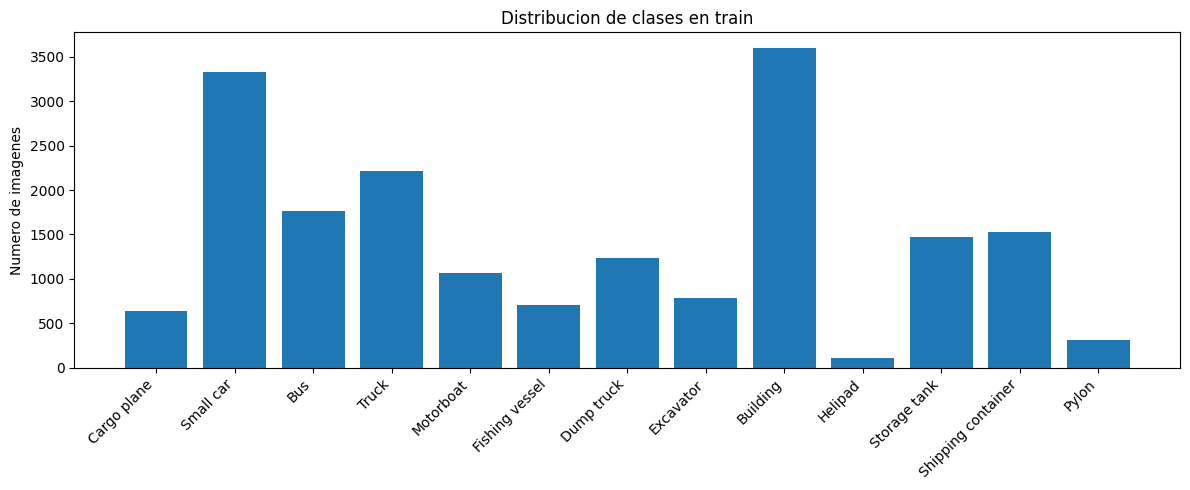

In [7]:
plt.figure(figsize=(12, 5))
plt.bar(summary['category'], summary['num_images'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Numero de imagenes')
plt.title('Distribucion de clases en train')
plt.tight_layout()
plt.show()


In [8]:
most_common = summary.iloc[summary['num_images'].idxmax()]
least_common = summary.iloc[summary['num_images'].idxmin()]
ratio = most_common['num_images'] / least_common['num_images']
print(f"Clase mayoritaria: {most_common['category']} ({most_common['num_images']} imagenes)")
print(f"Clase minoritaria: {least_common['category']} ({least_common['num_images']} imagenes)")
print(f"Ratio mayoritaria/minoritaria: {ratio:.1f}x")


Clase mayoritaria: Building (3594 imagenes)
Clase minoritaria: Helipad (111 imagenes)
Ratio mayoritaria/minoritaria: 32.4x


In [9]:
def load_geoimage(filename):
    if not HAS_RASTERIO:
        raise ImportError('Este notebook usa rasterio para leer .tif, igual que ffNN_example.ipynb.')
    warnings.filterwarnings('ignore', category=NotGeoreferencedWarning)
    with rasterio.open(DATA_ROOT / filename, 'r') as src_raster:
        img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=src_raster.profile['dtype'])
        for band in range(src_raster.count):
            img[:, :, band] = src_raster.read(band + 1)
    return img


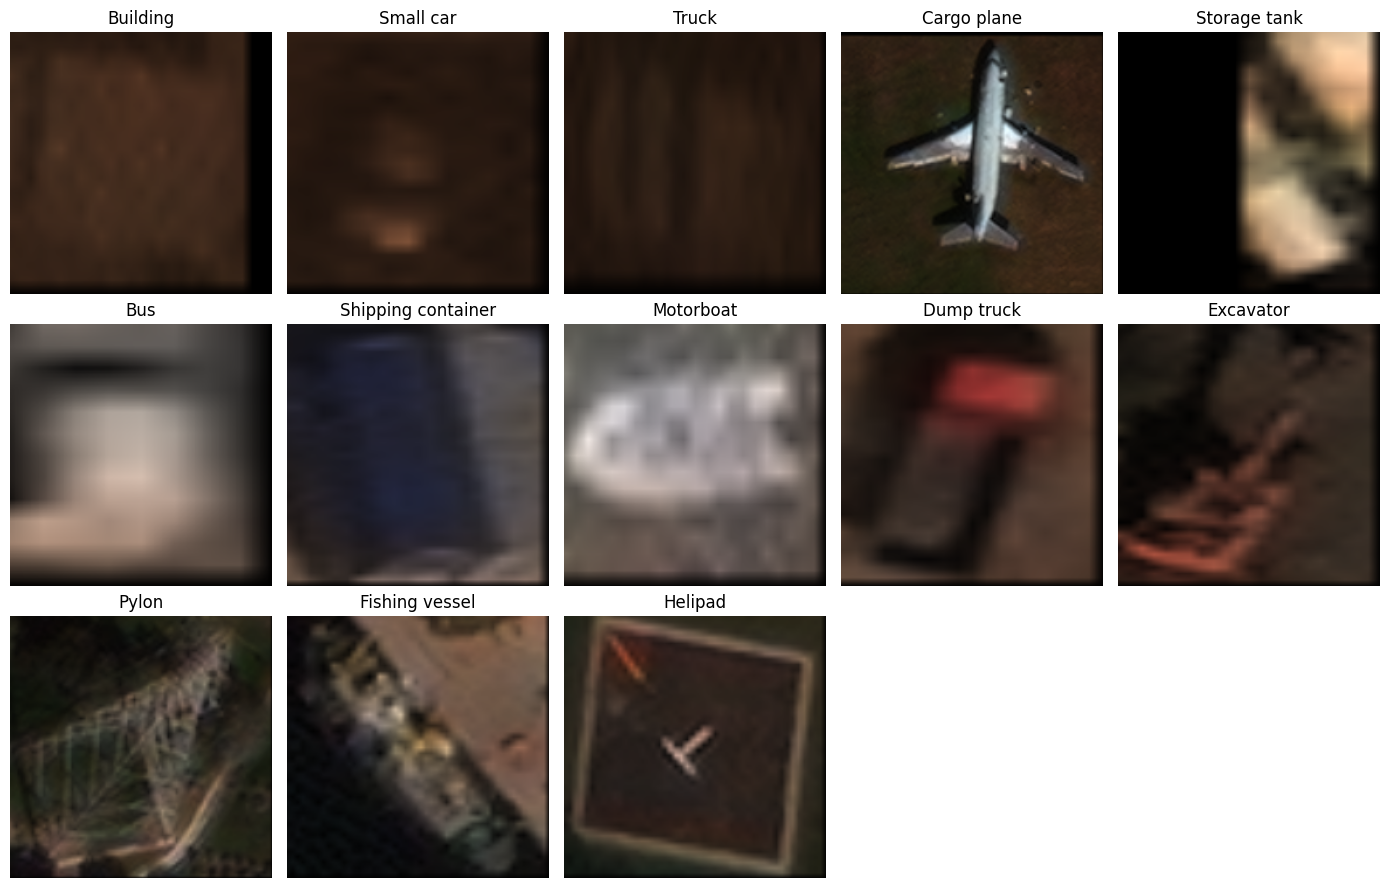

In [10]:
if HAS_RASTERIO:
    examples = df.groupby('category', sort=False).head(1)
    n_cols = 5
    n_rows = int(np.ceil(len(examples) / n_cols))
    plt.figure(figsize=(14, 3 * n_rows))
    for i, (_, row) in enumerate(examples.iterrows(), start=1):
        plt.subplot(n_rows, n_cols, i)
        plt.imshow(load_geoimage(row['filename']))
        plt.title(row['category'])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [11]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.15, random_state=42, shuffle=True, stratify=df['category'])
split_summary = pd.concat([
    train_df['category'].value_counts().reindex(category_names).rename('train'),
    val_df['category'].value_counts().reindex(category_names).rename('val'),
], axis=1)
split_summary


,train,val
category,,
Cargo plane,540,95
Small car,2825,499
Bus,1503,265
Truck,1878,332
Motorboat,909,160
Fishing vessel,600,106
Dump truck,1051,185
Excavator,671,118
Building,3055,539


## Conclusiones

- Usaremos `xview_ann_train.json` como fuente de verdad para etiquetas y rutas de entrenamiento.
- El dataset esta desbalanceado, asi que mas adelante conviene probar `class_weight` y metricas por clase.
- El test no tiene etiquetas publicas; solo se usara para generar `prediction.json` y `submission.zip`.
